=== train.csv ===
 No material  feedrate  clamp_pressure tool_condition machining_finalized passed_visual_inspection
  1      wax         6             4.0         unworn                 yes                      yes
  2      wax        20             4.0         unworn                 yes                      yes
  3      wax         6             3.0         unworn                 yes                      yes
  4      wax         6             2.5         unworn                  no                      NaN
  5      wax        20             3.0         unworn                  no                      NaN
  6      wax         6             4.0           worn                 yes                       no
  7      wax        20             4.0           worn                  no                      NaN
  8      wax        20             4.0           worn                 yes                       no
  9      wax        15             4.0           worn                 yes                  

C:\Users\bourg\AppData\Local\Temp\ipykernel_27892\2373765722.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot([data_unworn, data_worn], labels=["unworn","worn"], patch_artist=True,
C:\Users\bourg\AppData\Local\Temp\ipykernel_27892\2373765722.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax4.boxplot([dp_unworn, dp_worn], labels=["unworn","worn"], patch_artist=True,


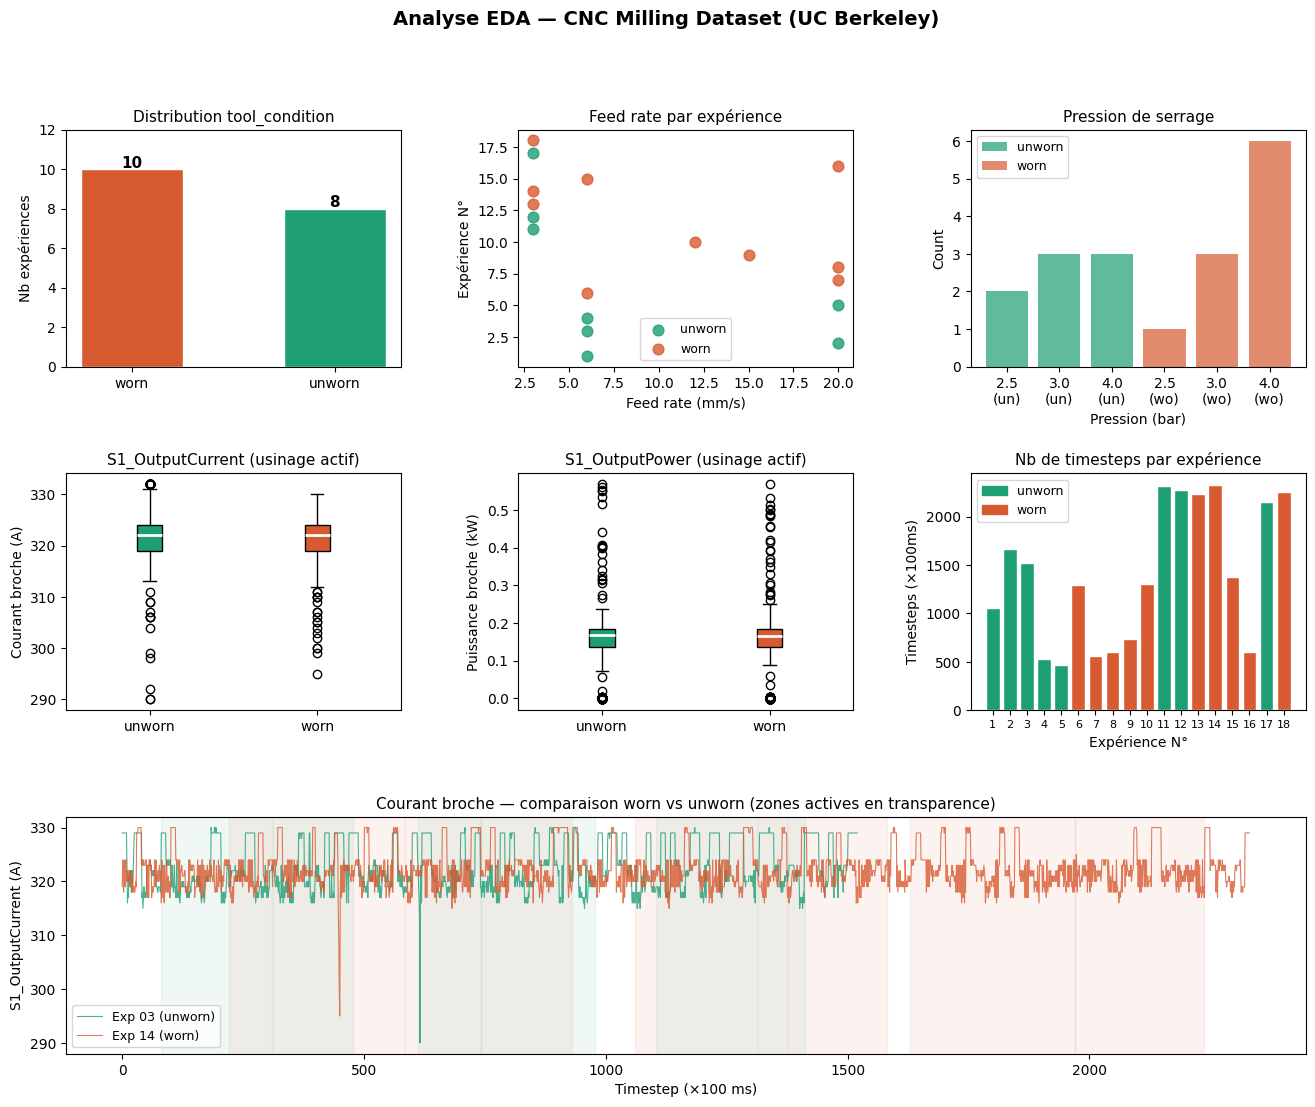


✓ Figure sauvegardée → c:\Users\bourg\OneDrive - DVHE\Bureau\ESILV\stage_furtwangen\dataset_1\eda_cnc.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import glob, os

# Répertoire de base : dossier du notebook
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()

# ── 1. TRAIN.CSV ─────────────────────────────────────────────────────────────
train_path = os.path.join(BASE_DIR, "train.csv")
train = pd.read_csv(train_path)
print("=== train.csv ===")
print(train.to_string(index=False))

# ── 2. CHARGER TOUS LES EXPERIMENTS ──────────────────────────────────────────
files = sorted(glob.glob(os.path.join(BASE_DIR, "experiment_*.csv")))
exps = {}
for f in files:
    eid = int(os.path.basename(f).split("_")[1].split(".")[0])
    df = pd.read_csv(f)
    df["exp_id"] = eid
    df["tool_condition"] = train.loc[train["No"] == eid, "tool_condition"].values[0]
    exps[eid] = df

all_df = pd.concat(exps.values(), ignore_index=True)

print(f"\n=== Données fusionnées ===")
print(f"Shape total : {all_df.shape}")
print(f"Colonnes    : {list(all_df.columns)}")
print(f"\nMachining_Process unique : {all_df['Machining_Process'].unique()}")
print(f"\nValeurs manquantes :\n{all_df.isnull().sum()[all_df.isnull().sum() > 0]}")

# Filtrer sur les phases d'usinage actif
active_labels = ["Layer 1 Up","Layer 1 Down","Layer 2 Up","Layer 2 Down","Layer 3 Up","Layer 3 Down"]
active = all_df[all_df["Machining_Process"].isin(active_labels)].copy()
print(f"\nLignes en usinage actif : {len(active)} / {len(all_df)}")

# ── 3. STATS PAR CONDITION D'OUTIL ───────────────────────────────────────────
key_signals = [
    "S1_OutputCurrent", "S1_OutputPower", "S1_CurrentFeedback",
    "X1_OutputCurrent", "Y1_OutputCurrent", "Z1_CurrentFeedback"
]
print("\n=== Statistiques clés par tool_condition (usinage actif) ===")
print(active.groupby("tool_condition")[key_signals].agg(["mean","std"]).round(3).to_string())

# ── 4. FIGURE ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Analyse EDA — CNC Milling Dataset (UC Berkeley)", fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

colors = {"unworn": "#1D9E75", "worn": "#D85A30"}

# 4a. Distribution des labels
ax0 = fig.add_subplot(gs[0, 0])
counts = train["tool_condition"].value_counts()
bars = ax0.bar(counts.index, counts.values, color=[colors[c] for c in counts.index], edgecolor="white", width=0.5)
ax0.set_title("Distribution tool_condition", fontsize=11)
ax0.set_ylabel("Nb expériences")
for b, v in zip(bars, counts.values):
    ax0.text(b.get_x() + b.get_width()/2, v + 0.1, str(v), ha="center", fontsize=11, fontweight="bold")
ax0.set_ylim(0, counts.max() + 2)

# 4b. Feed rate vs tool condition
ax1 = fig.add_subplot(gs[0, 1])
for cond, grp in train.groupby("tool_condition"):
    ax1.scatter(grp["feedrate"], grp["No"], label=cond, color=colors[cond], s=60, alpha=0.8)
ax1.set_title("Feed rate par expérience", fontsize=11)
ax1.set_xlabel("Feed rate (mm/s)")
ax1.set_ylabel("Expérience N°")
ax1.legend(fontsize=9)

# 4c. Clamp pressure distribution
ax2 = fig.add_subplot(gs[0, 2])
for cond, grp in train.groupby("tool_condition"):
    cp = grp["clamp_pressure"].value_counts().sort_index()
    ax2.bar([str(v) + f"\n({cond[:2]})" for v in cp.index], cp.values, color=colors[cond], alpha=0.7, label=cond)
ax2.set_title("Pression de serrage", fontsize=11)
ax2.set_xlabel("Pression (bar)")
ax2.set_ylabel("Count")
ax2.legend(fontsize=9)

# 4d. Courant broche (S1_OutputCurrent) — boxplot worn vs unworn
ax3 = fig.add_subplot(gs[1, 0])
data_worn   = active[active["tool_condition"]=="worn"]["S1_OutputCurrent"].dropna()
data_unworn = active[active["tool_condition"]=="unworn"]["S1_OutputCurrent"].dropna()
bp = ax3.boxplot([data_unworn, data_worn], labels=["unworn","worn"], patch_artist=True,
                 medianprops=dict(color="white", linewidth=2))
for patch, cond in zip(bp["boxes"], ["unworn","worn"]):
    patch.set_facecolor(colors[cond])
ax3.set_title("S1_OutputCurrent (usinage actif)", fontsize=11)
ax3.set_ylabel("Courant broche (A)")

# 4e. S1_OutputPower boxplot
ax4 = fig.add_subplot(gs[1, 1])
dp_worn   = active[active["tool_condition"]=="worn"]["S1_OutputPower"].dropna()
dp_unworn = active[active["tool_condition"]=="unworn"]["S1_OutputPower"].dropna()
bp2 = ax4.boxplot([dp_unworn, dp_worn], labels=["unworn","worn"], patch_artist=True,
                  medianprops=dict(color="white", linewidth=2))
for patch, cond in zip(bp2["boxes"], ["unworn","worn"]):
    patch.set_facecolor(colors[cond])
ax4.set_title("S1_OutputPower (usinage actif)", fontsize=11)
ax4.set_ylabel("Puissance broche (kW)")

# 4f. Durée des expériences (nb de lignes)
ax5 = fig.add_subplot(gs[1, 2])
lengths = [(eid, len(df), df["tool_condition"].iloc[0]) for eid, df in exps.items()]
lengths.sort()
eids, lens, conds = zip(*lengths)
bar_colors = [colors[c] for c in conds]
ax5.bar([str(e) for e in eids], lens, color=bar_colors, edgecolor="white")
ax5.set_title("Nb de timesteps par expérience", fontsize=11)
ax5.set_xlabel("Expérience N°")
ax5.set_ylabel("Timesteps (×100ms)")
ax5.tick_params(axis="x", labelsize=8)
from matplotlib.patches import Patch
ax5.legend(handles=[Patch(color=colors["unworn"], label="unworn"), Patch(color=colors["worn"], label="worn")], fontsize=9)

# 4g. Série temporelle S1_OutputCurrent — exp worn vs unworn
ax6 = fig.add_subplot(gs[2, :])
for eid, cond in [(3, "unworn"), (14, "worn")]:
    df_plot = exps[eid]
    ax6.plot(df_plot.index, df_plot["S1_OutputCurrent"], label=f"Exp {eid:02d} ({cond})",
             color=colors[cond], alpha=0.8, linewidth=0.8)
    # Zones d'usinage actif
    for proc in active_labels:
        mask = df_plot["Machining_Process"] == proc
        if mask.any():
            idx = df_plot.index[mask]
            ax6.axvspan(idx[0], idx[-1], alpha=0.07, color=colors[cond])
ax6.set_title("Courant broche — comparaison worn vs unworn (zones actives en transparence)", fontsize=11)
ax6.set_xlabel("Timestep (×100 ms)")
ax6.set_ylabel("S1_OutputCurrent (A)")
ax6.legend(fontsize=9)

# Sauvegarde de la figure dans le même dossier que le notebook
output_path = os.path.join(BASE_DIR, "eda_cnc.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"\n✓ Figure sauvegardée → {output_path}")